## Churn analysis

Goal: identify the main churn dynamics, quantify revenue at risk, and define which customer segments should be prioritized for retention actions.


In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("dataset_churn.csv")
df_raw = pd.read_csv(DATA_PATH, na_values=["NA", " ", ""])
cols_to_drop = [c for c in df_raw.columns if c.startswith("Unnamed") or c == "customerID"]
df_raw = df_raw.drop(columns=cols_to_drop)
df_raw.head(5)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,NaN,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,NaN,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,NaN,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,NaN,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Churn balance:", df_raw["Churn"].value_counts(normalize=True).round(3).to_dict())
print("\nColumn types:")
print(df_raw.dtypes)
print("\nMissing values by column:")
print(df_raw.isna().sum()[df_raw.isna().sum() > 0])

Churn balance: {'No': 0.735, 'Yes': 0.265}

Column types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Missing values by column:
OnlineBackup       5634
TechSupport        1526
StreamingTV        1526
StreamingMovies    1526
TotalCharges       2122
dtype: int64


## Data cleaning


In [3]:
df = df_raw.copy()

# Rebuild missing total charges for customers with zero tenure.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["tenure"] * df["MonthlyCharges"])

services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for c in services:
    df[c] = df[c].fillna("No internet service")

# Target variable.
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df["tenure_bin"] = pd.cut(
    df["tenure"],
    [-1, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"],
)


## Objective 1: understand churn drivers


Customer characteristics associated with churn


In [4]:
print("Global churn rate:", round(df["Churn"].mean() * 100, 1), "%")

groups = {
    "DEMOGRAPHICS": ["gender", "SeniorCitizen", "Partner", "Dependents"],
    "CONTRACT": ["Contract", "PaperlessBilling", "PaymentMethod"],
    "SERVICES": ["InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "PhoneService", "MultipleLines"],
}

for group, cols in groups.items():
    print(f"\n{group}")
    for c in cols:
        print(" ", c, ":", (df.groupby(c)["Churn"].mean() * 100).round(1).to_dict())

print("\nTENURE")
print("  tenure_bin:", (df.groupby("tenure_bin", observed=True)["Churn"].mean() * 100).round(1).to_dict())
print("\nAverage numerical features by churn status:")
print(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(1))


Global churn rate: 26.5 %

DEMOGRAPHICS
  gender : {'Female': 26.9, 'Male': 26.2}
  SeniorCitizen : {0: 23.6, 1: 41.7}
  Partner : {'No': 33.0, 'Yes': 19.7}
  Dependents : {'No': 31.3, 'Yes': 15.5}

CONTRACT
  Contract : {'Month-to-month': 42.7, 'One year': 11.3, 'Two year': 2.8}
  PaperlessBilling : {'No': 16.3, 'Yes': 33.6}
  PaymentMethod : {'Bank transfer (automatic)': 16.7, 'Credit card (automatic)': 15.2, 'Electronic check': 45.3, 'Mailed check': 19.1}

SERVICES
  InternetService : {'DSL': 19.0, 'Fiber optic': 41.9, 'No': 7.4}
  OnlineSecurity : {'No': 41.8, 'No internet service': 7.4, 'Yes': 14.6}
  OnlineBackup : {'No': 40.8, 'No internet service': 25.6, 'Yes': 19.1}
  DeviceProtection : {'No': 39.1, 'No internet service': 7.4, 'Yes': 22.5}
  TechSupport : {'No': 41.6, 'No internet service': 7.4, 'Yes': 15.2}
  StreamingTV : {'No': 33.5, 'No internet service': 7.4, 'Yes': 30.1}
  StreamingMovies : {'No': 33.7, 'No internet service': 7.4, 'Yes': 29.9}
  PhoneService : {'No': 24.

Key charts


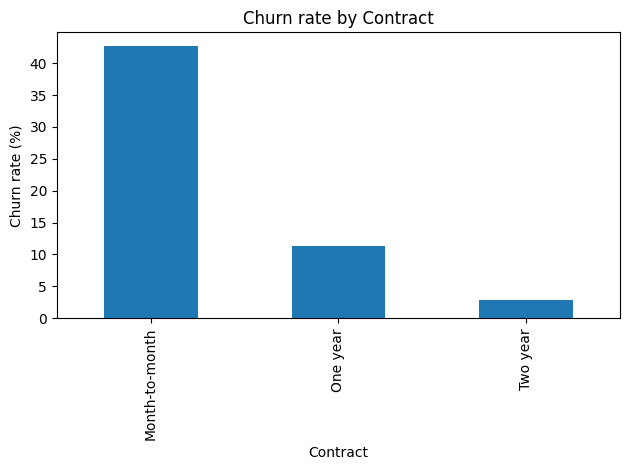

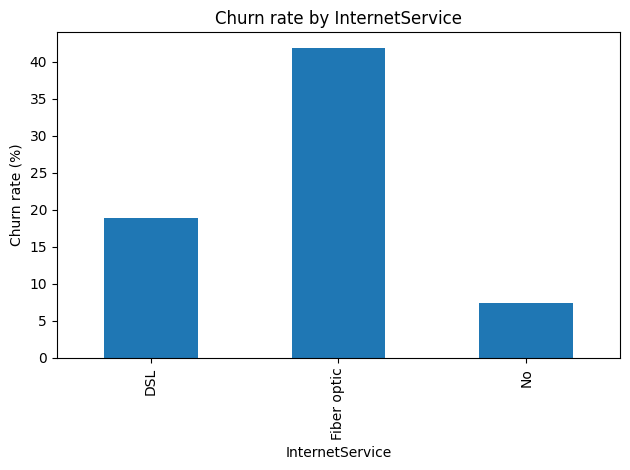

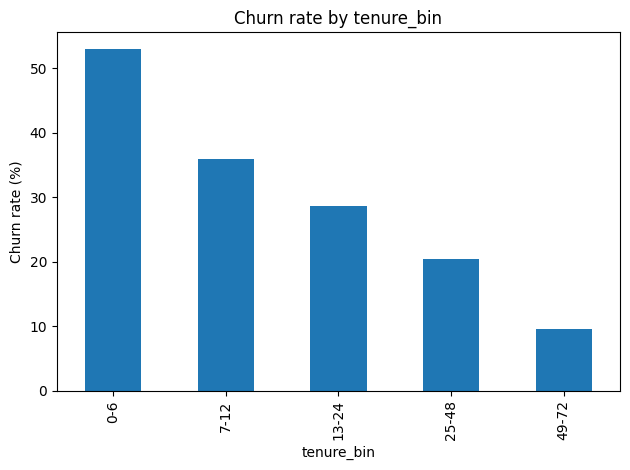

In [5]:
import matplotlib.pyplot as plt

for col in ["Contract", "InternetService", "tenure_bin"]:
    (df.groupby(col, observed=True)["Churn"].mean() * 100).plot.bar(title=f"Churn rate by {col}")
    plt.ylabel("Churn rate (%)")
    plt.tight_layout()
    plt.show()


Customer hypothesis: service depth


In [6]:
df["num_services"] = (
    df["PhoneService"].eq("Yes").astype(int)
    + df["MultipleLines"].eq("Yes").astype(int)
    + df["InternetService"].isin(["DSL", "Fiber optic"]).astype(int)
    + df[services].eq("Yes").sum(axis=1)
)

print("Churn rate by number of services:")
print((df.groupby("num_services")["Churn"].mean() * 100).round(1))
print("\nCorrelation between number of services and churn:", round(df["num_services"].corr(df["Churn"]), 3))


Churn rate by number of services:
num_services
1    11.4
2    31.2
3    42.5
4    34.6
5    29.2
6    25.7
7    18.4
8     7.1
9     9.5
Name: Churn, dtype: float64

Correlation between number of services and churn: -0.008


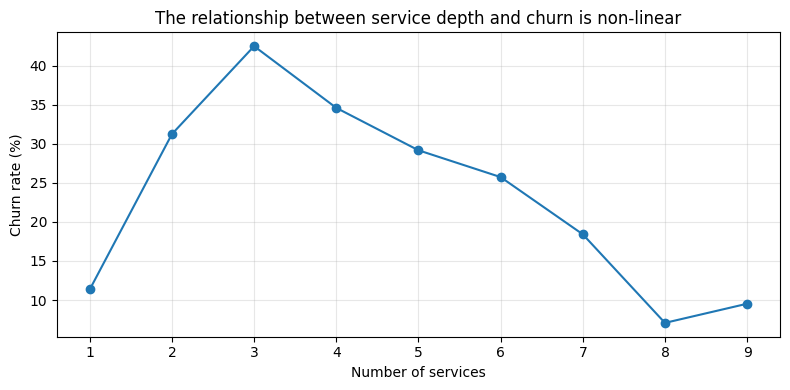

In [7]:
service_summary = (
    df.groupby("num_services")["Churn"]
    .agg(clients="size", churn_rate="mean")
    .reset_index()
)
service_summary["churn_rate"] *= 100

plt.figure(figsize=(8, 4))
plt.plot(service_summary["num_services"], service_summary["churn_rate"], marker="o")
plt.xlabel("Number of services")
plt.ylabel("Churn rate (%)")
plt.title("The relationship between service depth and churn is non-linear")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Business impact: revenue at risk

Churn should not only be measured by customer count. A segment is strategically important when it combines high churn probability with meaningful monthly revenue.


In [8]:
monthly_revenue = df["MonthlyCharges"].sum()
churned_monthly_revenue = df.loc[df["Churn"].eq(1), "MonthlyCharges"].sum()

print(f"Total monthly revenue: {monthly_revenue:,.0f}")
print(f"Monthly revenue from churned customers: {churned_monthly_revenue:,.0f}")
print(f"Share of monthly revenue at risk: {churned_monthly_revenue / monthly_revenue:.1%}")

risk_dimensions = ["Contract", "InternetService", "PaymentMethod", "tenure_bin"]
for col in risk_dimensions:
    summary = (
        df.groupby(col, observed=True)
        .agg(
            customers=("Churn", "size"),
            churn_rate=("Churn", "mean"),
            monthly_revenue=("MonthlyCharges", "sum"),
            revenue_at_risk=("MonthlyCharges", lambda s: s[df.loc[s.index, "Churn"].eq(1)].sum()),
        )
        .assign(
            churn_rate=lambda x: x["churn_rate"] * 100,
            risk_share=lambda x: x["revenue_at_risk"] / churned_monthly_revenue * 100,
        )
        .sort_values("revenue_at_risk", ascending=False)
    )
    print(f"\nRevenue at risk by {col}")
    display(summary.round({"churn_rate": 1, "monthly_revenue": 0, "revenue_at_risk": 0, "risk_share": 1}))


Total monthly revenue: 456,117
Monthly revenue from churned customers: 139,131
Share of monthly revenue at risk: 30.5%

Revenue at risk by Contract


,customers,churn_rate,monthly_revenue,revenue_at_risk,risk_share
Contract,,,,,
Month-to-month,3875,42.7,257294.0,120847.0,86.9
One year,1473,11.3,95817.0,14118.0,10.1
Two year,1695,2.8,103006.0,4165.0,3.0



Revenue at risk by InternetService


,customers,churn_rate,monthly_revenue,revenue_at_risk,risk_share
InternetService,,,,,
Fiber optic,3096,41.9,283284.0,114300.0,82.2
DSL,2421,19.0,140665.0,22529.0,16.2
No,1526,7.4,32167.0,2302.0,1.7



Revenue at risk by PaymentMethod


,customers,churn_rate,monthly_revenue,revenue_at_risk,risk_share
PaymentMethod,,,,,
Electronic check,2365,45.3,180345.0,84289.0,60.6
Bank transfer (automatic),1544,16.7,103745.0,20092.0,14.4
Credit card (automatic),1522,15.2,101232.0,17947.0,12.9
Mailed check,1612,19.1,70794.0,16804.0,12.1



Revenue at risk by tenure_bin


,customers,churn_rate,monthly_revenue,revenue_at_risk,risk_share
tenure_bin,,,,,
0-6,1481,52.9,81068.0,49896.0,35.9
25-48,1594,20.4,105093.0,27462.0,19.7
13-24,1024,28.7,62830.0,23082.0,16.6
49-72,2239,9.5,165564.0,19632.0,14.1
7-12,705,35.9,41562.0,19058.0,13.7


## Priority segments

The most useful retention targets are not necessarily the broadest categories. Crossing lifecycle, contract, product, and payment method helps identify concentrated pockets of risk.


In [9]:
priority_segments = (
    df.groupby(["Contract", "InternetService", "tenure_bin", "PaymentMethod"], observed=True)
    .agg(
        customers=("Churn", "size"),
        churn_rate=("Churn", "mean"),
        monthly_revenue=("MonthlyCharges", "sum"),
        revenue_at_risk=("MonthlyCharges", lambda s: s[df.loc[s.index, "Churn"].eq(1)].sum()),
    )
    .reset_index()
)

priority_segments = (
    priority_segments[priority_segments["customers"] >= 100]
    .assign(churn_rate=lambda x: x["churn_rate"] * 100)
    .sort_values(["revenue_at_risk", "churn_rate"], ascending=False)
)

display(priority_segments.head(12).round({"churn_rate": 1, "monthly_revenue": 0, "revenue_at_risk": 0}))


,Contract,InternetService,tenure_bin,PaymentMethod,customers,churn_rate,monthly_revenue,revenue_at_risk
22,Month-to-month,Fiber optic,0-6,Electronic check,440,75.5,35552.0,26921.0
30,Month-to-month,Fiber optic,13-24,Electronic check,255,58.8,22555.0,13354.0
34,Month-to-month,Fiber optic,25-48,Electronic check,286,49.0,26466.0,12947.0
26,Month-to-month,Fiber optic,7-12,Electronic check,191,61.3,16383.0,10245.0
2,Month-to-month,DSL,0-6,Electronic check,209,56.9,9537.0,5213.0
38,Month-to-month,Fiber optic,49-72,Electronic check,135,37.0,12992.0,4815.0
3,Month-to-month,DSL,0-6,Mailed check,192,45.3,8826.0,3964.0
32,Month-to-month,Fiber optic,25-48,Bank transfer (automatic),102,41.2,9345.0,3889.0
91,One year,Fiber optic,49-72,Electronic check,129,24.8,13037.0,3275.0
33,Month-to-month,Fiber optic,25-48,Credit card (automatic),102,32.4,9018.0,2929.0


## Lifecycle effect

Tenure is the strongest signal in the current model, so it is worth isolating the customer lifecycle effect before moving to prediction.


Churn rate by tenure and contract (%):


Contract,Month-to-month,One year,Two year
tenure_bin,,,
0-6,55.2,10.3,0.0
7-12,42.0,10.6,0.0
13-24,37.7,8.1,0.0
25-48,32.9,10.6,2.2
49-72,26.0,12.9,3.3



Customer count by tenure and contract:


Contract,Month-to-month,One year,Two year
tenure_bin,,,
0-6,1413,39,29
7-12,581,85,39
13-24,737,197,90
25-48,802,518,274
49-72,342,634,1263


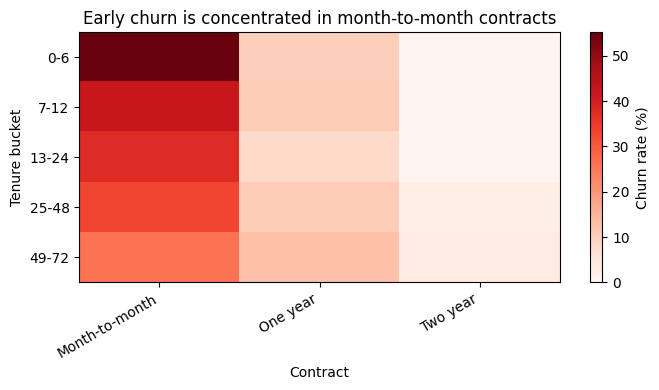

In [10]:
lifecycle = (
    df.pivot_table(
        index="tenure_bin",
        columns="Contract",
        values="Churn",
        aggfunc="mean",
        observed=True,
    )
    * 100
)

client_counts = df.pivot_table(
    index="tenure_bin",
    columns="Contract",
    values="Churn",
    aggfunc="size",
    observed=True,
)

print("Churn rate by tenure and contract (%):")
display(lifecycle.round(1))
print("\nCustomer count by tenure and contract:")
display(client_counts.astype(int))

plt.figure(figsize=(7, 4))
plt.imshow(lifecycle, cmap="Reds", aspect="auto")
plt.colorbar(label="Churn rate (%)")
plt.xticks(range(len(lifecycle.columns)), lifecycle.columns, rotation=30, ha="right")
plt.yticks(range(len(lifecycle.index)), lifecycle.index)
plt.title("Early churn is concentrated in month-to-month contracts")
plt.xlabel("Contract")
plt.ylabel("Tenure bucket")
plt.tight_layout()
plt.show()


## Objective 2: predict and prioritize customers


Baseline model


In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

y = df["Churn"]
features = df.drop(columns=["Churn", "tenure_bin"])
num = ["tenure", "MonthlyCharges", "TotalCharges", "num_services"]
cat = [c for c in features.columns if c not in num]

pre = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat),
])

X_tr, X_te, y_tr, y_te = train_test_split(features, y, test_size=0.2, stratify=y, random_state=42)

dummy = Pipeline([
    ("pre", pre),
    ("classifier", DummyClassifier(strategy="prior")),
])

dummy.fit(X_tr, y_tr)
dummy_proba = dummy.predict_proba(X_te)[:, 1]

print("Dummy ROC-AUC:", roc_auc_score(y_te, dummy_proba))
print(classification_report(y_te, dummy.predict(X_te), digits=3, zero_division=0))


Dummy ROC-AUC: 0.5
              precision    recall  f1-score   support

           0      0.735     1.000     0.847      1035
           1      0.000     0.000     0.000       374

    accuracy                          0.735      1409
   macro avg      0.367     0.500     0.423      1409
weighted avg      0.540     0.735     0.622      1409



Logistic regression model


In [12]:
import warnings

model = Pipeline([
    ("pre", pre),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    model_pred = model.predict(X_te)

print("ROC-AUC:", round(roc_auc_score(y_te, proba), 3))
print(classification_report(y_te, model_pred, digits=3))


ROC-AUC: 0.842
              precision    recall  f1-score   support

           0      0.903     0.722     0.802      1035
           1      0.505     0.786     0.615       374

    accuracy                          0.739      1409
   macro avg      0.704     0.754     0.709      1409
weighted avg      0.798     0.739     0.753      1409



## Model as a targeting tool

The model is most useful if it helps prioritize a limited retention effort. The lift table shows how much churn is captured when targeting only the highest-risk customers.


,targeted_share,customers_targeted,precision,recall,lift_vs_average,monthly_revenue_at_risk
0,Top 5%,70,0.743,0.139,2.80,4495.0
1,Top 10%,140,0.764,0.286,2.88,8828.0
2,Top 15%,211,0.701,0.396,2.64,11948.0
3,Top 20%,281,0.662,0.497,2.49,14794.0
4,Top 30%,422,0.573,0.647,2.16,18870.0


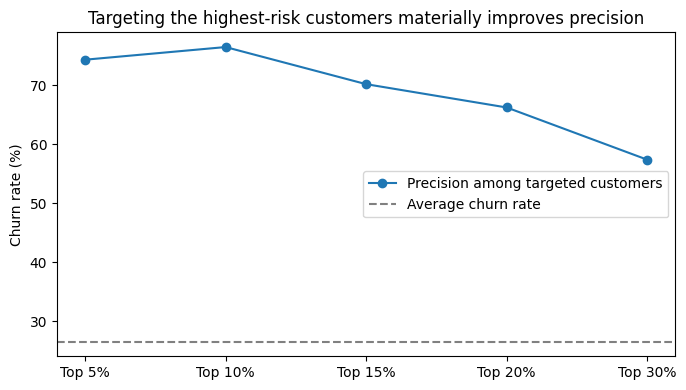

In [13]:
scored = X_te.copy()
scored["actual_churn"] = y_te.values
scored["predicted_churn_probability"] = proba
scored = scored.sort_values("predicted_churn_probability", ascending=False).reset_index(drop=True)

total_churners = scored["actual_churn"].sum()
base_rate = scored["actual_churn"].mean()
rows = []
for pct in [0.05, 0.10, 0.15, 0.20, 0.30]:
    top = scored.head(int(len(scored) * pct))
    precision = top["actual_churn"].mean()
    recall = top["actual_churn"].sum() / total_churners
    rows.append({
        "targeted_share": f"Top {int(pct * 100)}%",
        "customers_targeted": len(top),
        "precision": precision,
        "recall": recall,
        "lift_vs_average": precision / base_rate,
        "monthly_revenue_at_risk": top.loc[top["actual_churn"].eq(1), "MonthlyCharges"].sum(),
    })

lift_table = pd.DataFrame(rows)
display(lift_table.round({"precision": 3, "recall": 3, "lift_vs_average": 2, "monthly_revenue_at_risk": 0}))

plt.figure(figsize=(7, 4))
plt.plot(lift_table["targeted_share"], lift_table["precision"] * 100, marker="o", label="Precision among targeted customers")
plt.axhline(base_rate * 100, color="gray", linestyle="--", label="Average churn rate")
plt.ylabel("Churn rate (%)")
plt.title("Targeting the highest-risk customers materially improves precision")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
from sklearn.inspection import permutation_importance

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    importance = permutation_importance(
        model,
        X_te,
        y_te,
        scoring="roc_auc",
        n_repeats=10,
        random_state=42,
    )

importance_df = pd.DataFrame({
    "feature": X_te.columns,
    "importance": importance.importances_mean,
}).sort_values("importance", ascending=False)

display(importance_df.head(10))


,feature,importance
4,tenure,0.158228
7,InternetService,0.058139
17,MonthlyCharges,0.041805
14,Contract,0.038263
18,TotalCharges,0.012236
19,num_services,0.006508
8,OnlineSecurity,0.004733
11,TechSupport,0.003875
16,PaymentMethod,0.003363
13,StreamingMovies,0.002921
